## Install (Colab Only)

In [1]:
# install
!pip install pyepo
!pip install gurobipy
!pip install clarabel


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Remove the problematic hook from Google Colab.

In [2]:
import sys
sys.meta_path = [hook for hook in sys.meta_path if not any(keyword in str(hook) for keyword in ["google.colab"])]

# CaVE for Binary Linear Programs

This notebook introduces **CaVE** (Cone-Aligned Vector Estimation), a fast
end-to-end loss for predict-then-optimize problems where the inner
optimization is a **binary linear program (BLP)** - shortest path, knapsack,
TSP, vehicle routing, etc.

> Reference: Tang & Khalil, *CaVE: A Cone-Aligned Approach for Fast
> Predict-then-optimize with Binary Linear Programs*, CPAIOR 2024.
> Paper: <https://arxiv.org/abs/2312.07718>  Repo: <https://github.com/khalil-research/CaVE>


## 1 The Idea in One Paragraph

Most decision-focused losses (SPO+, DPO, PFYL, ...) call the solver **once
per training step** to turn the predicted cost into a decision. For a hard
MIP like CVRP that per-step solve dominates training time.

**CaVE replaces it with a QP projection.** For each training instance, the
true optimal vertex is the intersection of a small set of *binding* (tight)
constraints. The cost vectors that pick that vertex form a polyhedral cone -
the normal cone at the optimum. CaVE pre-computes the binding-constraint
normals once during data prep, then at every training step it just projects
the sense-flipped predicted cost onto that cone and minimizes
$1 - \cos(-\hat{\mathbf{c}}, \mathrm{proj})$.

PyEPO's `coneAlignedCosine` performs the projection with Clarabel
(interior-point QP) at `max_iter=3` (the **CaVE+** preset) so the projection
stays interior to the cone, giving a rich gradient.

This notebook runs **CVRP-20** (capacitated vehicle routing on 20 customers)
— the setting where CaVE's speedup is most dramatic in the paper. Each
Gurobi CVRP solve takes a few hundred milliseconds; the Clarabel cone
projection takes about an order of magnitude less.

We compare three methods:

- **SPO+** — calls Gurobi every batch.
- **CaVE+** — Clarabel QP projection every batch.
- **CaVE-Hybrid** — Clarabel QP with probability `solve_ratio = 0.3`,
  otherwise a cheap heuristic (blend of normalized cost and average
  constraint normal).


## 2 Setup


In [3]:
import time
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import pyepo
from pyepo.data.dataset import optDataset, optDatasetConstrs, collate_tight_constraints
from pyepo.model.grb import vrpRCIModel

In [4]:
torch.manual_seed(0)
np.random.seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")

device = cuda


## 3 Problem: CVRP-20

Capacitated Vehicle Routing on 20 customers + 1 depot, served by 5
vehicles with capacity 30. The Gurobi formulation uses 2-degree
constraints with **lazy rounded-capacity cuts**; the cuts at the optimum
are tracked for CaVE cone extraction.

Hyperparameters match the CaVE paper:

| setting | value |
|---|---|
| `num_data` (train + test) | 1000 + 100 |
| `num_feat` | 10 |
| `deg` | 4 |
| `noise_width` | 0.5 |
| `num_nodes` | 21 (1 depot + 20 customers) |
| `capacity` | 30 |
| `num_vehicle` | 5 |
| `processes` | 1 |


In [5]:
NUM_DATA = 1000
NUM_TEST = 100
NUM_FEAT = 10
DEG = 4
NOISE = 0.5
NUM_NODES = 21          # 1 depot + 20 customers
CAPACITY = 30
NUM_VEHICLE = 5

BATCH = 32
EPOCHS = 10
LR = 5e-2
PROCESSES = 1

SPLIT_SEED = 135        # train_test_split random_state (matches CaVE paper)
DATA_SEED = 42          # pyepo.data.tsp.genData seed (VRP edge costs use TSP-style generator)

## 4 Two Datasets, One Optimization Model

SPO+ and CaVE consume slightly different datasets:

- **`optDataset`** - features, true costs, true solutions, true objectives.
  This is what SPO+ uses.
- **`optDatasetConstrs`** - the same four items **plus** the matrix of
  tight-constraint normals at each optimum. CaVE needs this to project.

Building `optDatasetConstrs` is a bit slower than `optDataset` because it
also extracts the active binding set after each solve. You pay this cost
once per dataset.


## 5 Predictor

A single linear layer that maps a feature vector to a per-edge cost. The
same network is used for all three methods so the only thing that differs
across runs is the loss.


In [6]:
class LinearPred(nn.Module):
    def __init__(self, num_feat, num_cost):
        super().__init__()
        self.linear = nn.Linear(num_feat, num_cost)

    def forward(self, x):
        return self.linear(x)

## 6 Training Loops

Three near-identical loops: SPO+, CaVE+, CaVE-Hybrid. The CaVE loops
receive one extra item per batch (`tight_ctrs`) and feed it to
`coneAlignedCosine` instead of `SPOPlus`. CaVE-Hybrid only differs from
CaVE+ in the `solve_ratio` argument.


In [7]:
def regret(predmodel, optmodel, loader):
    return pyepo.metric.regret(predmodel, optmodel, loader)


def train_spo(optmodel, train_loader, test_loader, num_feat, num_epochs=EPOCHS, lr=LR):
    pred = LinearPred(num_feat, optmodel.num_cost).to(device)
    opt = torch.optim.Adam(pred.parameters(), lr=lr)
    loss_fn = pyepo.func.SPOPlus(optmodel, processes=PROCESSES)
    regrets = [regret(pred, optmodel, test_loader)]
    times = [0.0]
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for ep in range(num_epochs):
        for x, c, w, z in train_loader:
            x, c, w, z = x.to(device), c.to(device), w.to(device), z.to(device)
            cp = pred(x)
            loss = loss_fn(cp, c, w, z)
            opt.zero_grad(); loss.backward(); opt.step()
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        regrets.append(regret(pred, optmodel, test_loader))
    return regrets, times


def train_cave(optmodel, train_loader, test_loader, num_feat,
               num_epochs=EPOCHS, lr=LR, solve_ratio=1.0):
    pred = LinearPred(num_feat, optmodel.num_cost).to(device)
    opt = torch.optim.Adam(pred.parameters(), lr=lr)
    loss_fn = pyepo.func.coneAlignedCosine(optmodel, solve_ratio=solve_ratio, processes=PROCESSES)
    regrets = [regret(pred, optmodel, test_loader)]
    times = [0.0]
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for ep in range(num_epochs):
        for x, c, w, z, tight_ctrs in train_loader:
            # tight_ctrs stays on CPU (Clarabel + avg both CPU-bound)
            x = x.to(device)
            cp = pred(x)
            loss = loss_fn(cp, tight_ctrs)
            opt.zero_grad(); loss.backward(); opt.step()
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        regrets.append(regret(pred, optmodel, test_loader))
    return regrets, times

## 7 Run Three Methods on CVRP-20

Generate data once, build both datasets, then train SPO+ / CaVE+ /
CaVE-Hybrid back to back.

Expect roughly 1-2 hours total — dataset construction solves 2,200
CVRP-20 instances with Gurobi, and SPO+ then re-solves every batch.
CaVE+ and CaVE-Hybrid spend almost all their time on the Clarabel QP
projection (much cheaper than a Gurobi MIP), so they finish in minutes.


### Generate Data

In [8]:
# VRP edge costs are sampled via TSP-style Euclidean generator
feats, costs = pyepo.data.tsp.genData(
    num_data=NUM_DATA + NUM_TEST, num_features=NUM_FEAT, num_nodes=NUM_NODES,
    deg=DEG, noise_width=NOISE, seed=DATA_SEED,
)
x_train, x_test, c_train, c_test = train_test_split(
    feats, costs, test_size=NUM_TEST, random_state=SPLIT_SEED,
)

### Create Model

In [9]:
# CVRP-20 instance shared across train/test/eval
np.random.seed(DATA_SEED)
demands = np.random.rand(NUM_NODES - 1) * 10
optmodel = vrpRCIModel(num_nodes=NUM_NODES, demands=demands, capacity=CAPACITY, num_vehicle=NUM_VEHICLE)

Set parameter Username
Set parameter LicenseID to value 2785503
Academic license - for non-commercial use only - expires 2027-02-28


### Build Dataset and Dataloader

In [10]:
# build datasets (one-time cost, not included in training time)
tick = time.time()
ds_train = optDataset(optmodel, x_train, c_train)
ds_test  = optDataset(optmodel, x_test,  c_test)
print(f"  optDataset        built in {time.time() - tick:.1f}s")
tick = time.time()
ds_train_c = optDatasetConstrs(optmodel, x_train, c_train)
print(f"  optDatasetConstrs built in {time.time() - tick:.1f}s")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:31<00:00,  1.09it/s]


  optDataset        built in 799.0s


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [13:42<00:00,  1.22it/s]

  optDatasetConstrs built in 822.1s


In [11]:
# dataloader
loader_spo  = DataLoader(ds_train,   batch_size=BATCH, shuffle=True)
loader_test = DataLoader(ds_test,    batch_size=BATCH, shuffle=False)
loader_cave = DataLoader(ds_train_c, batch_size=BATCH, shuffle=True, collate_fn=collate_tight_constraints)

### Training

In [12]:
results = {}  # method -> (regrets, times)

In [13]:
# SPO+
print(f"\n--- SPO+ ---", flush=True)
spo_regrets, spo_times = train_spo(optmodel, loader_spo, loader_test, NUM_FEAT)
print(f"  wall = {spo_times[-1]:6.1f}s  final regret = {spo_regrets[-1]:.4f}")
results["SPO+"] = (spo_regrets, spo_times)

if device.type == "cuda":
    torch.cuda.empty_cache()


--- SPO+ ---
  wall = 1164.3s  final regret = 0.0588


In [14]:
# CaVE+ (solve_ratio = 1.0)
print(f"\n--- CaVE+ ---", flush=True)
cave_regrets, cave_times = train_cave(optmodel, loader_cave, loader_test, NUM_FEAT,
                                       solve_ratio=1.0)
print(f"  wall = {cave_times[-1]:6.1f}s  final regret = {cave_regrets[-1]:.4f}")
results["CaVE+"] = (cave_regrets, cave_times)

if device.type == "cuda":
    torch.cuda.empty_cache()


--- CaVE+ ---
  wall =  142.8s  final regret = 0.0544


In [15]:
# CaVE-Hybrid (solve_ratio = 0.3)
print(f"\n--- CaVE-Hybrid ---", flush=True)
hyb_regrets, hyb_times = train_cave(optmodel, loader_cave, loader_test, NUM_FEAT,
                                     solve_ratio=0.3)
print(f"  wall = {hyb_times[-1]:6.1f}s  final regret = {hyb_regrets[-1]:.4f}")
results["CaVE-Hybrid"] = (hyb_regrets, hyb_times)

if device.type == "cuda":
    torch.cuda.empty_cache()


--- CaVE-Hybrid ---
  wall =  110.6s  final regret = 0.0718


## 8 Learning Curves

Regret over epochs on the left, regret over wall-clock on the right. The
wall-clock view is where CaVE's speedup is visible — it reaches comparable
regret in a fraction of the time SPO+ needs.


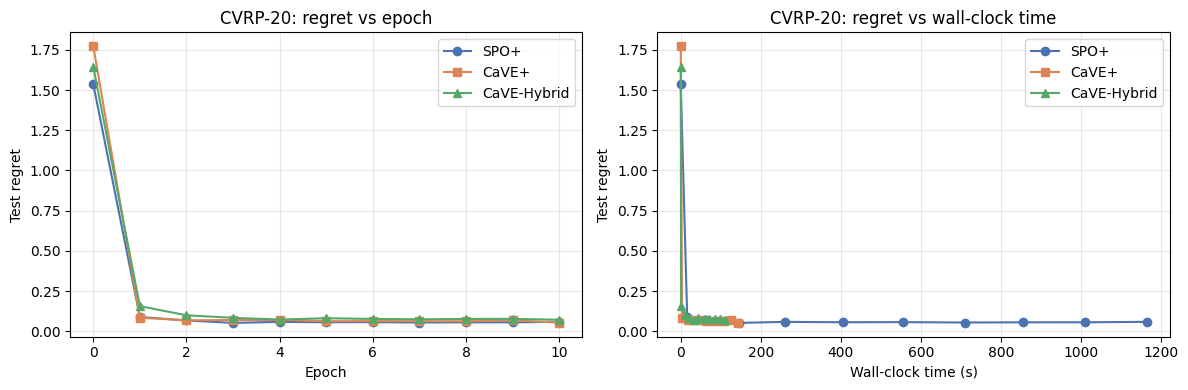

In [16]:
colors = {"SPO+": "#4C72B0", "CaVE+": "#DD8452", "CaVE-Hybrid": "#55A868"}
markers = {"SPO+": "o", "CaVE+": "s", "CaVE-Hybrid": "^"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, (regrets, times) in results.items():
    epochs = list(range(len(regrets)))
    ax1.plot(epochs, regrets, marker=markers[name], label=name, color=colors[name])
    ax2.plot(times,  regrets, marker=markers[name], label=name, color=colors[name])
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Test regret")
ax1.set_title("CVRP-20: regret vs epoch")
ax1.grid(alpha=0.3); ax1.legend()
ax2.set_xlabel("Wall-clock time (s)"); ax2.set_ylabel("Test regret")
ax2.set_title("CVRP-20: regret vs wall-clock time")
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

## 9 Speed vs Quality Summary

Bar chart: training wall-clock (log y-axis) on the left, final test regret
on the right.


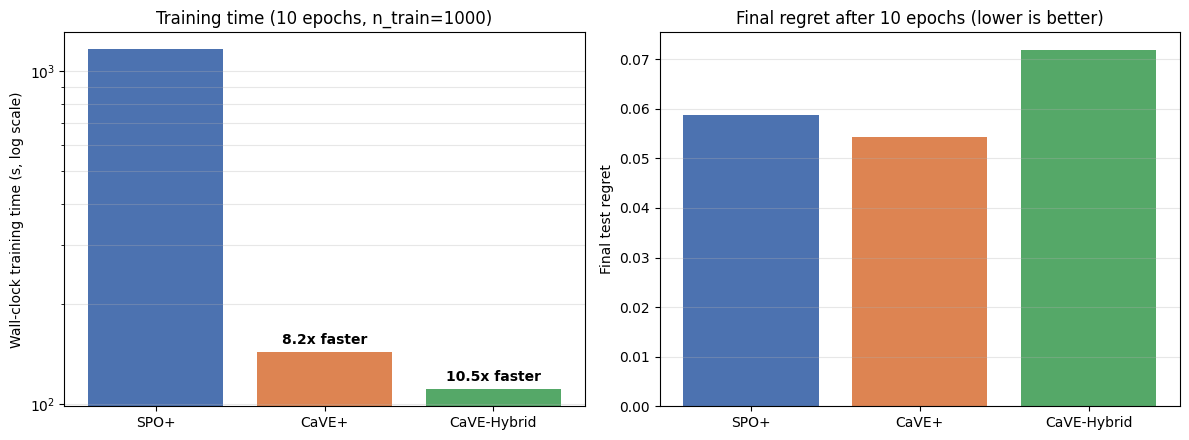

In [17]:
methods = list(results.keys())
walls   = [results[m][1][-1] for m in methods]
regs    = [results[m][0][-1] for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(methods))
bar_colors = [colors[m] for m in methods]

bars = ax1.bar(x, walls, color=bar_colors)
spo_wall = results["SPO+"][1][-1]
for bar, m in zip(bars, methods):
    if m == "SPO+":
        continue
    speedup = spo_wall / bar.get_height()
    ax1.annotate(f"{speedup:.1f}x faster",
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 4), textcoords="offset points",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_yscale("log")
ax1.set_xticks(x); ax1.set_xticklabels(methods)
ax1.set_ylabel("Wall-clock training time (s, log scale)")
ax1.set_title(f"Training time ({EPOCHS} epochs, n_train={NUM_DATA})")
ax1.grid(axis="y", which="both", alpha=0.3)

ax2.bar(x, regs, color=bar_colors)
ax2.set_xticks(x); ax2.set_xticklabels(methods)
ax2.set_ylabel("Final test regret")
ax2.set_title(f"Final regret after {EPOCHS} epochs (lower is better)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

## 10 Takeaways

- **CaVE+ matches SPO+ regret at order-of-magnitude less training time** on hard MIPs like CVRP. The win comes from replacing the per-step Gurobi MIP solve with a small QP projection onto the cone of binding-constraint normals at the true optimum.

- **CaVE+** (`solve_ratio=1.0`, `max_iter=3`) under-converges the Clarabel QP on purpose — the projection stays interior to the cone and yields a richer gradient than the exact projection.

- **CaVE-Hybrid** (`solve_ratio<1`) skips a fraction of the Clarabel calls via a cheap heuristic branch (blend of normalized predicted cost and average binding-constraint normal). Trades sub-percent extra regret for several-times further speedup.

- **Usage:** wrap the Gurobi `optmodel` with `pyepo.data.dataset.optDatasetConstrs` + `collate_tight_constraints`, then train with `pyepo.func.coneAlignedCosine(optmodel, solve_ratio=0.3)`.